In [1]:
library(cellAdmix)
library(ggplot2)

theme_set(theme_bw())

Loading required package: NMF

Loading required package: registry

Loading required package: rngtools

Loading required package: cluster

NMF - BioConductor layer [OK] | Shared memory capabilities [NO: bigmemory] | Cores 2/2

  To enable shared memory capabilities, try: install.extras('
NMF
')



In [2]:
devtools::load_all()

ℹ Loading cellAdmix


This tutorial will use a downsampled version of the dataset in NSCLC_tutorial_fulldata.ipynb, which is already stored in the cellAdmix package for ease of testing. Let's load the downsampled data:

In [3]:
data(cell_meta)
data(df)

In [4]:
# first downsampling cells to reduce runtime
df_sub <- samp_ct_equal(df, cell_meta, num.cells.samp=1000)

The function below takes ~20 minutes to run

In [ ]:
# k specifies the number of factors to extract
# h specifies the knn neighborhood size
# nmol_dsamp determines how many molecules we want to further downsample to before running NMF (for runtime purposes)
res <- run_knn_nmf(df_sub, k=10, h=20, nmol.dsamp=2000, n.cores=10)

NMF algorithm: 'ls-nmf'

Multiple runs: 30

Mode: parallel (2/96 core(s))



Runs: |                                                  |   0%

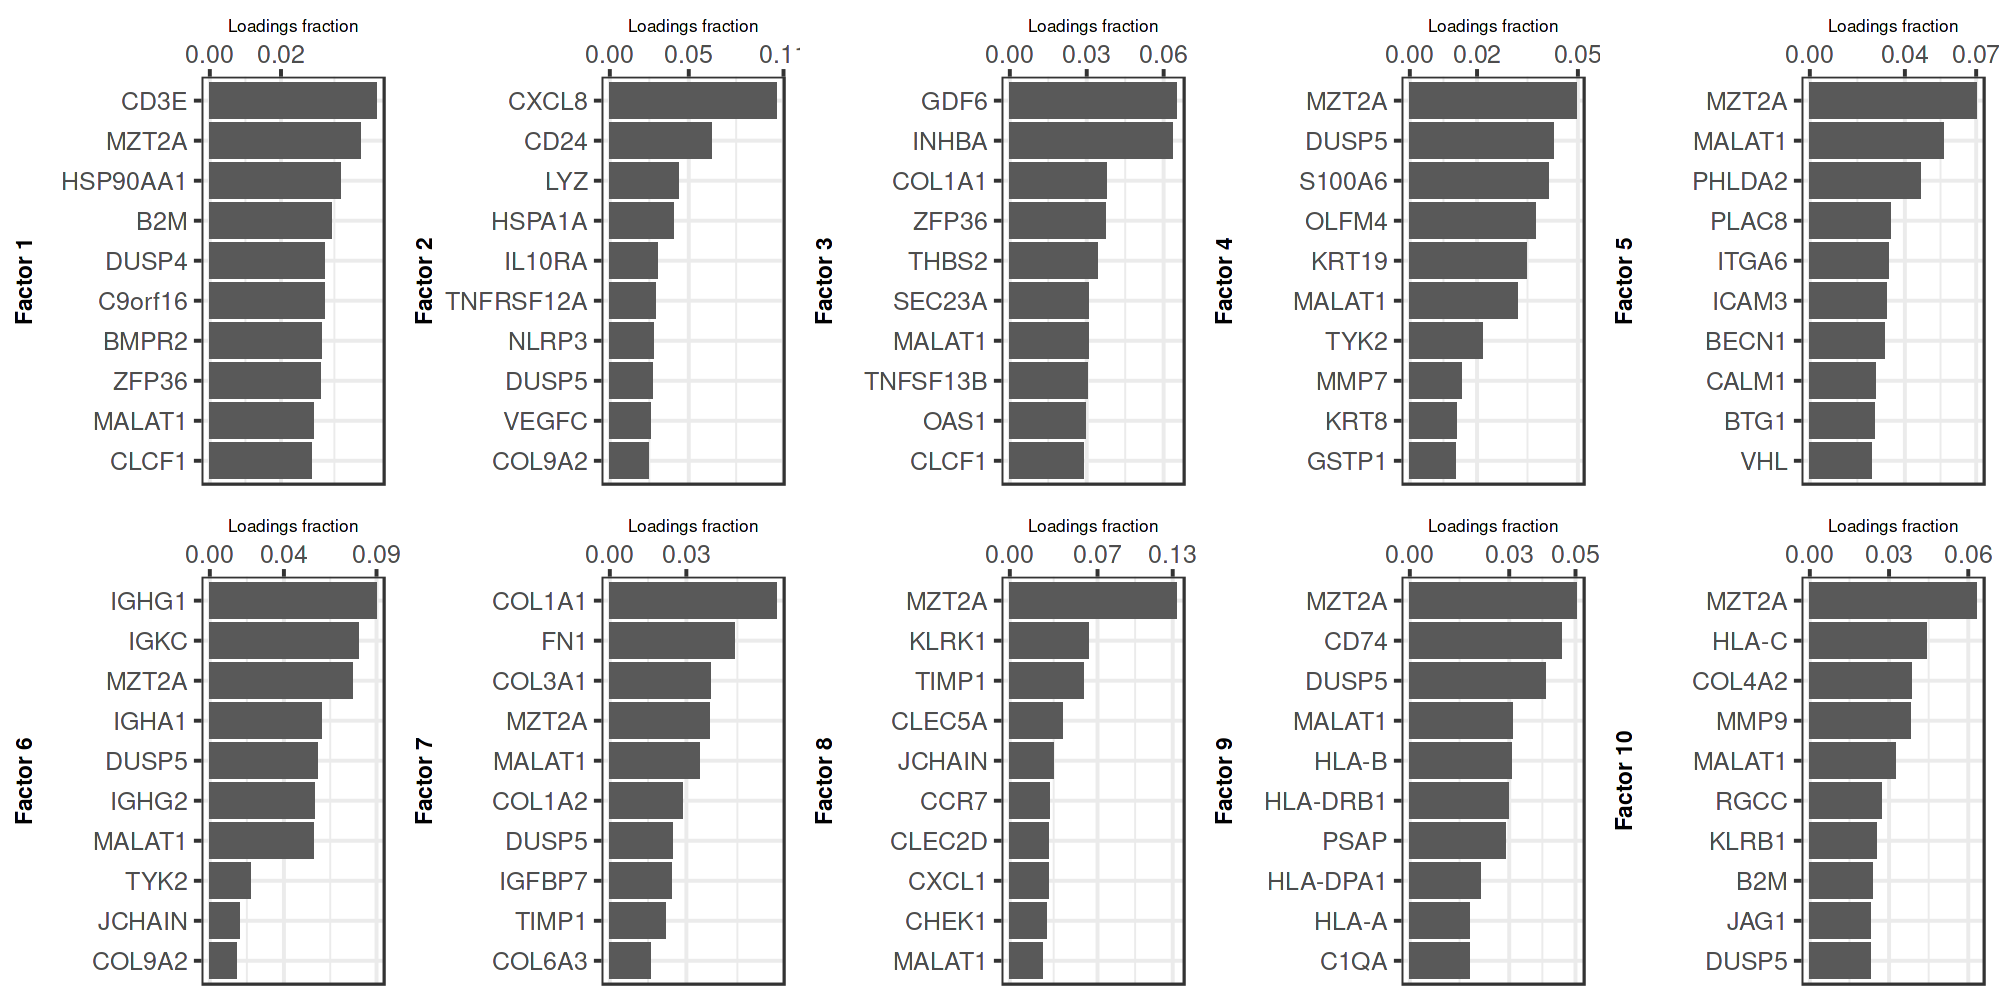

In [11]:
# Plot some top loading genes for each factor
options(repr.plot.width=10, repr.plot.height=5, repr.plot.res=200)
plot_nmf_loadings(res, nplt.row=2)

Here, factor 1 appears to represent admixture from malignant cells since several of the top loading genes are KRT19, KRT8, and KRT17, which are specific malignant markers. Note that the dataset downsampling step may cause these results to look slightly different from yours, so you will need to identify which factor corresponds to the malignant cell admixture and modify the following cell.


In [38]:
malignant_admix_factor <- 4

In [39]:
# num_nn is the number of nearest neighbors parameter in the CRF graph
crf_res <- run_crf_all(df, res, num.nn=10, n.cores=10)

# append the crf result to the df, as the molecule ordering is the same
df$factor <- crf_res[,1]

# this appended a column 'factor' indicating which factor each molecule has been assigned to
head(df, 3)

,x,y,z,gene,cell,celltype,mol_id,factor
,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>
28869682,4646.4480,31194.32,1.6,MZT2A,c_1_25_164,fibroblast,23192620,7
17559401,1888.3743,29484.82,6.4,COL4A1,c_1_12_3420,fibroblast,14749418,7
31104365,924.5403,31388.39,4.8,MMP2,c_1_26_2007,fibroblast,25130331,7


In [40]:
# now, remove the molecules assigned to the admixture factor from fibroblasts

# subset to only fibroblasts
df_fib <- df[df$celltype=='fibroblast',]
df_fib_cln <- filter(df_fib, !(factor %in% malignant_admix_factor))

print(paste0('Number of molecules originally: ', nrow(df_fib)))
print(paste0('Number of molecules after cleaning: ', nrow(df_fib_cln)))

[1] "Number of molecules originally: 15505"
[1] "Number of molecules after cleaning: 14993"


In [41]:
# compute a clean counts matrix from molecule level data
so_cln <- get_counts_meta_seurat(df_fib_cln)
meta_cln <- so_cln@meta.data
dat_cln <- so_cln[['RNA']]$counts

so_orig <- get_counts_meta_seurat(df[df$celltype=='fibroblast',])
meta_orig <- so_orig@meta.data
dat_orig <- so_orig[['RNA']]$counts

cells_both <- intersect(colnames(dat_orig),colnames(dat_cln))
dat_orig <- dat_orig[,cells_both]
dat_cln <- dat_cln[,cells_both]

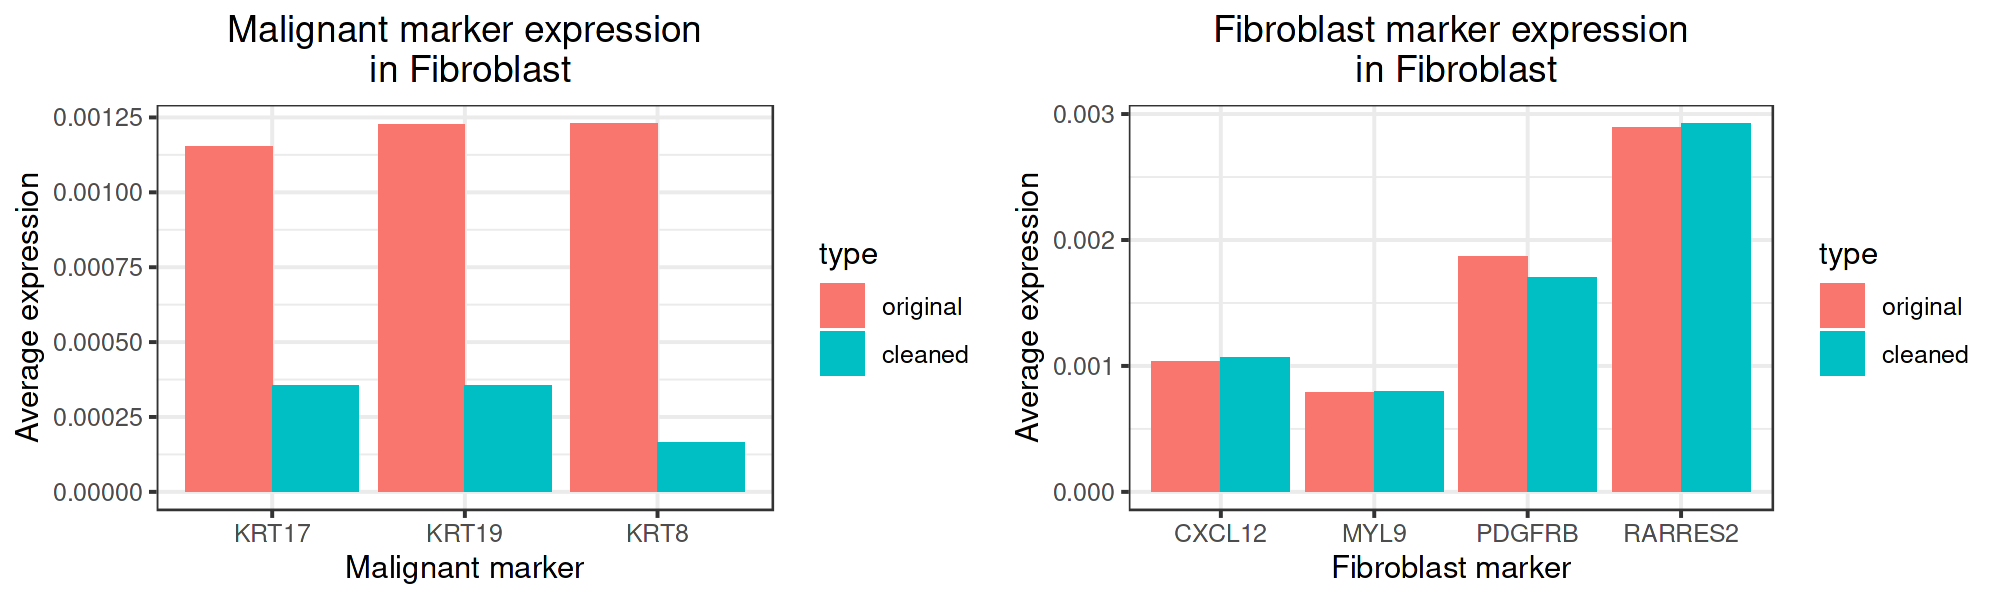

In [42]:
options(repr.plot.width = 10, repr.plot.height = 3, repr.plot.res = 200)

plot_expression_comparison(
    as.matrix(dat_orig), as.matrix(dat_cln),
    markers.native=c('MYL9','CXCL12','PDGFRB','RARRES2'),
    markers.admix=c('KRT19','KRT8','KRT17'),
    admixture.type='Malignant', native.type='Fibroblast'
)

As this data is greatly downsampled, the performance is significantly reduced. However, some reduction in malignant marker expression can still be seen.